# Supervised ML  on the aging project
### DTI over the Corpus Callosum and Aging
#### Daniela M. Pinzon 
##### 2025


### **Step 0. Loading and organizing the dataframe**

In [5]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Upload files
tracto_path='/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025'

listsub = ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '19', '20', '21', '22', '23', '24', '25', '26',
             '27', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '41', '46', '47', '48', '49', '50', '51']

# CREATE CSV allsub DTI FILE FOR GIVEN CC and metric
dti_metric_list=['FA']
CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(tracto_path, f'sub-{subj}_{dti_metric}_tractometry_mergedTOMs.csv')
            if os.path.exists(file_path):
                data_sub = pd.read_csv(file_path, sep=";")
                list_CCx_val.append(data_sub[CCx].values)
            else:
                print(f"File not found: {file_path}")

        # Convert list of arrays → DataFrame
        dfCCx = pd.DataFrame(list_CCx_val)

        # Rename columns seg_2, seg_3, ... up to length
        new_col_names = [f"seg_{i}" for i in range(2, 2 + dfCCx.shape[1])]
        dfCCx.columns = new_col_names

        # Save to CSV
        out_file = f"{CCx}_{dti_metric}.csv"
        #dfCCx.to_csv(out_file, index_label="Index")

        #print(f"Saved {out_file} with shape {dfCCx.shape}")

dfCCx.head()

,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,...,seg_90,seg_91,seg_92,seg_93,seg_94,seg_95,seg_96,seg_97,seg_98,seg_99
0,0.217662,0.210098,0.247803,0.268852,0.290765,0.323112,0.343515,0.357370,0.369495,0.379671,...,0.360924,0.332037,0.314768,0.299466,0.298382,0.308184,0.298445,0.273005,0.262117,0.256813
1,0.253484,0.262070,0.292464,0.332066,0.363638,0.387894,0.380612,0.380712,0.392777,0.405353,...,0.406321,0.379443,0.356917,0.352207,0.348463,0.339861,0.316460,0.295315,0.280481,0.261766
2,0.260242,0.270165,0.298168,0.317146,0.341831,0.349599,0.360562,0.364213,0.387899,0.417723,...,0.401845,0.398161,0.385322,0.370853,0.351907,0.341978,0.327453,0.311015,0.270894,0.284198
3,0.284478,0.273726,0.305177,0.316505,0.333896,0.341914,0.340203,0.352046,0.366992,0.396127,...,0.406781,0.398832,0.383533,0.360845,0.344475,0.325261,0.298865,0.274800,0.256411,0.242831
4,0.299203,0.279968,0.325303,0.330661,0.334002,0.345579,0.356900,0.364836,0.374161,0.378739,...,0.403711,0.402517,0.389317,0.374304,0.378468,0.367895,0.331832,0.293978,0.256532,0.244655


### 1. Pre-processing of the demographic Information

In [6]:
# Install openpyxl if not already installed
#%pip install openpyxl --quiet

# Upload the demographic file
sub_id_file='/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/Subjects_ID.xlsx'
sub_id = pd.read_excel(sub_id_file)
#drop the index column
#sub_id = sub_id.drop(columns=['Index'])


sub_id

,sub,sex,age,group,JND_P,IHD
0,sub-01,F,25,Y,9.5600,0.534027
1,sub-02,M,27,Y,6.6900,0.570600
2,sub-03,F,28,Y,12.9200,-0.140120
3,sub-05,F,21,Y,1.9500,0.488581
4,sub-06,F,25,Y,2.5400,0.578001
5,sub-08,F,67,O,4.4800,0.419239
6,sub-09,M,73,O,9.6300,0.246470
7,sub-10,F,64,O,7.2700,0.253942
8,sub-11,F,21,Y,1.6200,0.268078
9,sub-12,M,21,Y,3.6800,0.115833


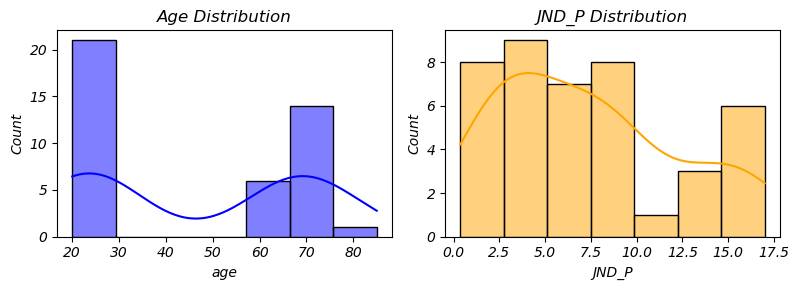

In [7]:
age = sub_id['age'].dropna()
jnd = sub_id['JND_P'].dropna()
# subplots histogram with KDE for age and JND_P distributions
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(age, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')
sns.histplot(jnd, kde=True, ax=axes[1], color='orange')
axes[1].set_title('JND_P Distribution')
plt.tight_layout()
plt.show()


In [ ]:
CC_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis'
#sub-46_FA_tractometry_MergedTOMs_last.csv
#CCx_list=['CC_4']

data_frames = []
for CCx in CCx_list:
    for dti_metric in dti_metric_list:
        print(f'Merging data for {CCx} and metric {dti_metric}')
        file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
        print(CCx_df.shape)
        CCx_df = pd.read_csv(file_path)
        data_frames = pd.concat([sub_id, CCx_df], axis=1)
        #save merged dataframe
        dfCCx = data_frames
        #dfCCx.to_csv(CCx +'_'+dti_metric+'.csv', index=False)

dfCCx

Merging data for CC_1 and metric FA


NameError: name 'CCx_df' is not defined

### 2. Data Visualization 

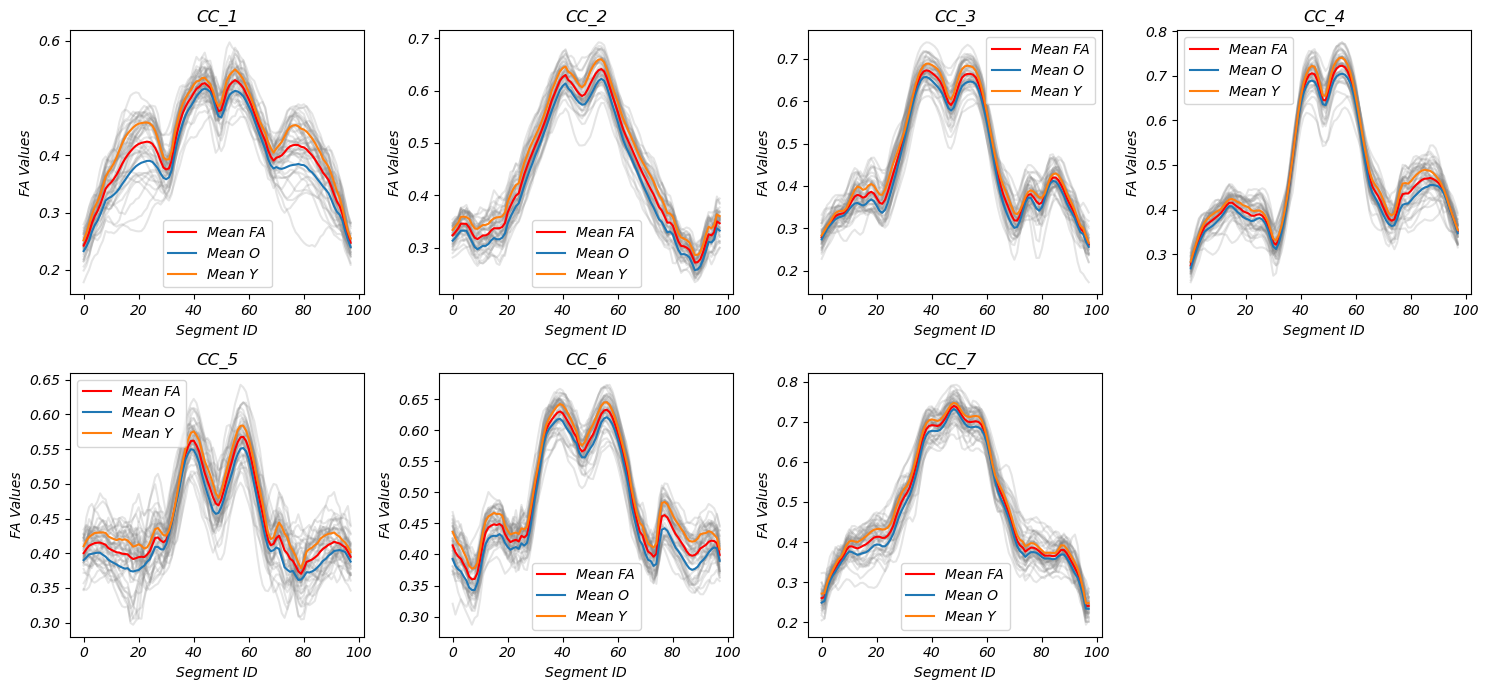

      sub group  age  JND_P sex       IHD
0  sub-01     Y   25   9.56   F  0.534027
1  sub-02     Y   27   6.69   M  0.570600
2  sub-03     Y   28  12.92   F -0.140120
3  sub-05     Y   21   1.95   F  0.488581
4  sub-06     Y   25   2.54   F  0.578001


In [ ]:
# Paths and CC list
CC_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis'
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

# Create subplots (2x4 grid for 7 plots)
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")

    #get the subject ID and group information from dfCCx, and drop the remaining columns
    sub_ID = dfCCx[['sub', 'group', 'age', 'JND_P', 'sex', 'IHD']]
    # drop the columns that are not numeric :
    dfCCx = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex','IHD'], axis=1)
    # Select only numeric columns
    feature_cols = dfCCx.select_dtypes(include=['float', 'int']).columns
    
    # X-axis: 98 nodes
    x = range(len(feature_cols))

    # Plot each row as a line
    for idx, row in dfCCx.iterrows():
        axs[i].plot(x, row[feature_cols].values, alpha=0.2, color='gray')
# Plot the mean line
    mean_values = dfCCx[feature_cols].mean()
    axs[i].plot(x, mean_values.values, color='red', label='Mean FA')
    # mean by 2 group : Young and Old
    dfCCx['group'] = sub_id['group']
    mean_by_group = dfCCx.groupby('group')[feature_cols].mean()
    for group in mean_by_group.index:
        axs[i].plot(x, mean_by_group.loc[group].values, label=f'Mean {group}')

    axs[i].set_title(f'{CCx}')
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')
    axs[i].legend()
# Remove unused subplot (8th slot)
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

print(sub_ID.head())


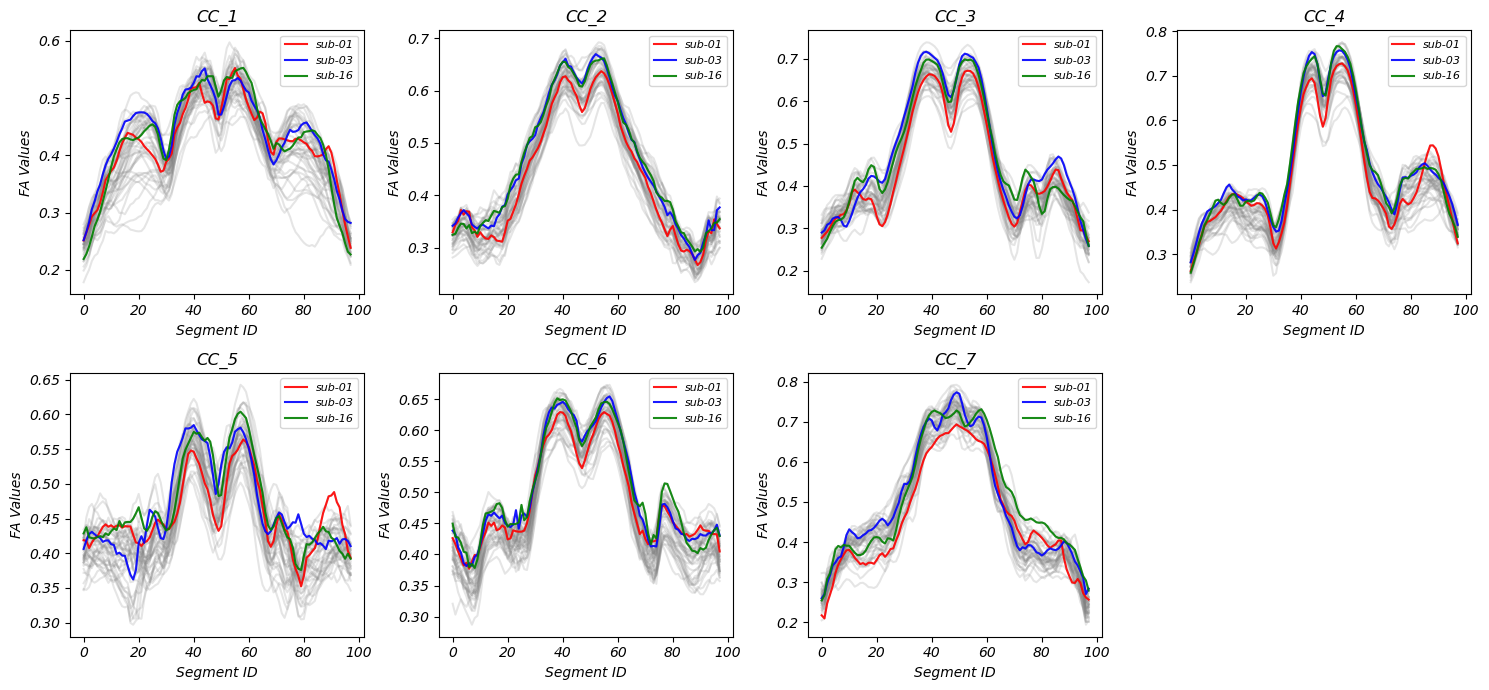

sub-01: JND_P = 9.56, Age = 25
sub-03: JND_P = 12.92, Age = 28
sub-16: JND_P = 9.06, Age = 20


In [ ]:
# Create subplots
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

# Subjects to highlight
subject_ids = ['sub-01', 'sub-03', 'sub-16']
subject_colors = {'sub-01': 'red', 'sub-03': 'blue','sub-16': 'green'}

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    df = pd.read_csv(file_path)

    # Keep a copy with metadata
    meta = df[['sub', 'group', 'age', 'JND_P', 'sex', 'IHD']]
    # Keep only FA values
    df_fa = df.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    feature_cols = df_fa.select_dtypes(include=['float', 'int']).columns
    x = range(len(feature_cols))

    # Plot all subjects (gray)
    for idx in df_fa.index:
        axs[i].plot(x, df_fa.loc[idx, feature_cols].values,
                    alpha=0.2, color='gray')
    # Plot selected subjects
    for subject_id in subject_ids:
        mask = meta['sub'] == subject_id
        if mask.any():
            row = df_fa[mask].iloc[0]
            axs[i].plot(
                x,
                row[feature_cols].values,
                alpha=0.9,
                linewidth=1.5,
                color=subject_colors[subject_id],
                label=subject_id
            )
    # Formatting
    axs[i].set_title(CCx)
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')

    # Avoid duplicate legends
    handles, labels = axs[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[i].legend(by_label.values(), by_label.keys(), fontsize=8)

# Remove empty subplot
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# print the JND values and age for the highlighted subjects 
for subject_id in subject_ids:
    mask = meta['sub'] == subject_id
    if mask.any():
        jnd_value = meta[mask]['JND_P'].values[0]
        age_value = meta[mask]['age'].values[0]
        print(f"{subject_id}: JND_P = {jnd_value}, Age = {age_value}")

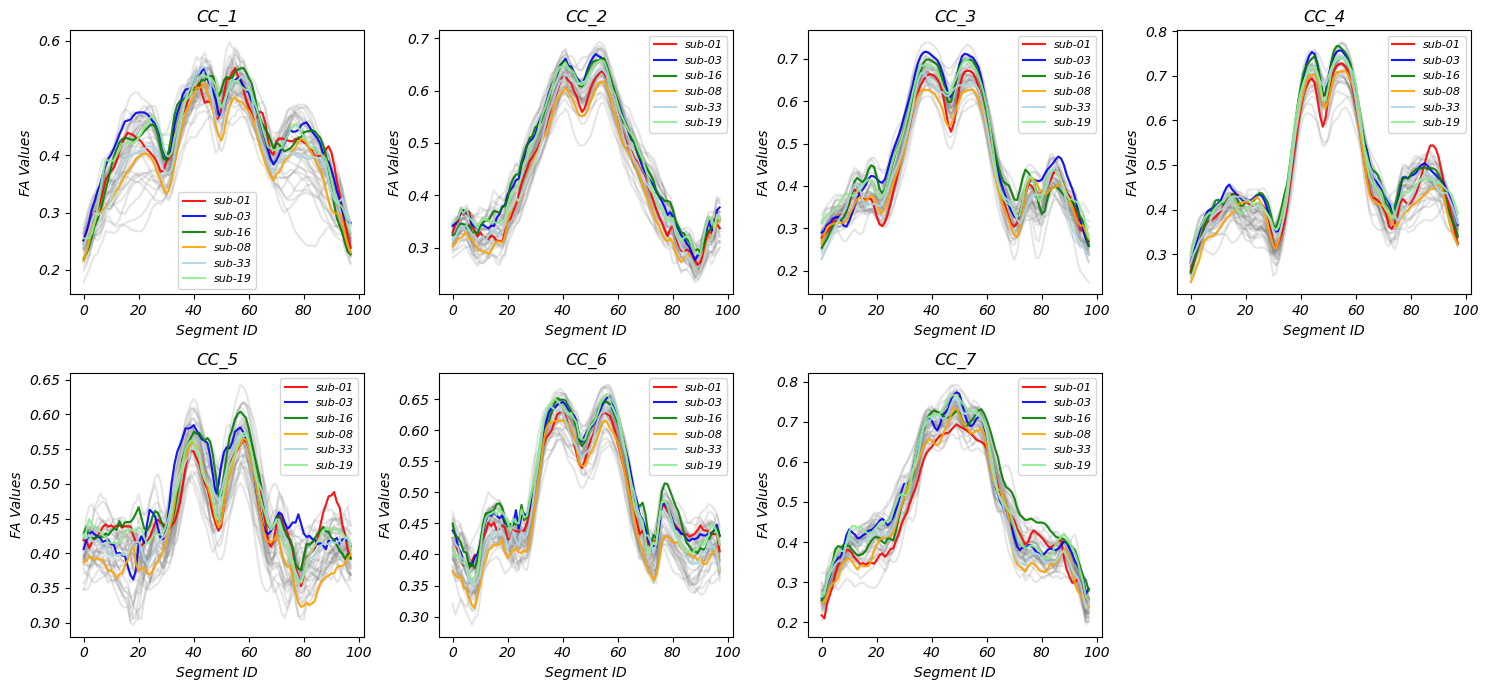

sub-01: JND_P = 9.56, Age = 25
sub-03: JND_P = 12.92, Age = 28
sub-16: JND_P = 9.06, Age = 20
sub-08: JND_P = 4.48, Age = 67
sub-33: JND_P = 4.37, Age = 67
sub-19: JND_P = 6.68, Age = 74


In [ ]:
# Odd subjects in the Old group

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

# Subjects to highlight
subject_ids = ['sub-01', 'sub-03', 'sub-16','sub-08', 'sub-33', 'sub-19']
subject_colors = {'sub-01': 'red', 'sub-03': 'blue','sub-16': 'green', 'sub-08': 'orange', 'sub-33': 'lightblue','sub-19': 'lightgreen'}

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    df = pd.read_csv(file_path)

    # Keep a copy with metadata
    meta = df[['sub', 'group', 'age', 'JND_P', 'sex']]
    # Keep only FA values
    df_fa = df.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    feature_cols = df_fa.select_dtypes(include=['float', 'int']).columns
    x = range(len(feature_cols))

    # Plot all subjects (gray)
    for idx in df_fa.index:
        axs[i].plot(x, df_fa.loc[idx, feature_cols].values,
                    alpha=0.2, color='gray')
    # Plot selected subjects
    for subject_id in subject_ids:
        mask = meta['sub'] == subject_id
        if mask.any():
            row = df_fa[mask].iloc[0]
            axs[i].plot(
                x,
                row[feature_cols].values,
                alpha=0.9,
                linewidth=1.5,
                color=subject_colors[subject_id],
                label=subject_id
            )
    # Formatting
    axs[i].set_title(CCx)
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')

    # Avoid duplicate legends
    handles, labels = axs[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[i].legend(by_label.values(), by_label.keys(), fontsize=8)

# Remove empty subplot
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# print the JND values and age for the highlighted subjects 
for subject_id in subject_ids:
    mask = meta['sub'] == subject_id
    if mask.any():
        jnd_value = meta[mask]['JND_P'].values[0]
        age_value = meta[mask]['age'].values[0]
        print(f"{subject_id}: JND_P = {jnd_value}, Age = {age_value}")

### 3. Simple analysis - global effect
JND∼FAmean​+Age

In [ ]:
# Get the mean FA values for each subject for each CC, and save it in a new dataframe   
df_mean_FA = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    #dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    
    # get the mean values along the segments for each subject
    mean_values_df = mean_values.mean(axis=1)
    df_mean_FA[CCx] = mean_values_df   

    # get the med-segments for each CC tract, and then save the mean (from 48-5 and 48+5)
    center_CCx = mean_values.iloc[:, 43:53]  # Assuming 98 segments, get the middle ten segments
    center_mean = center_CCx.mean(axis=1)
    df_mean_FA[CCx + '_center'] = center_mean

# dataframe 
df_mean_FA['JND_P'] = sub_ID['JND_P']
df_mean_FA['group'] = sub_ID['group']
df_mean_FA

,CC_1,CC_1_center,CC_2,CC_2_center,CC_3,CC_3_center,CC_4,CC_4_center,CC_5,CC_5_center,CC_6,CC_6_center,CC_7,CC_7_center,JND_P,group
0,0.422197,0.492387,0.433916,0.593148,0.442326,0.600152,0.473096,0.657154,0.454889,0.472627,0.488529,0.572409,0.459040,0.678908,9.5600,Y
1,0.435293,0.523926,0.460370,0.637466,0.461996,0.655273,0.490447,0.692954,0.465242,0.494818,0.501403,0.599087,0.500431,0.703427,6.6900,Y
2,0.438349,0.509818,0.461592,0.638913,0.478353,0.659184,0.499815,0.713948,0.465016,0.534610,0.502382,0.605154,0.494540,0.739482,12.9200,Y
3,0.403365,0.482450,0.437396,0.611071,0.445059,0.627508,0.468086,0.665718,0.443992,0.471680,0.484982,0.578450,0.477138,0.729868,1.9500,Y
4,0.450210,0.518673,0.479953,0.639970,0.489614,0.657896,0.495008,0.715649,0.460854,0.537240,0.501980,0.623595,0.506974,0.764931,2.5400,Y
5,0.390697,0.474799,0.415654,0.572149,0.432174,0.580062,0.459599,0.673997,0.424889,0.478341,0.460773,0.566081,0.457369,0.699350,4.4800,O
6,0.401987,0.495506,0.427530,0.594186,0.442259,0.626667,0.461006,0.628343,0.437943,0.463733,0.477700,0.579515,0.484520,0.738491,9.6300,O
7,0.410109,0.501930,0.437462,0.591888,0.450372,0.607378,0.489683,0.705092,0.471926,0.535322,0.496140,0.587990,0.475404,0.686323,7.2700,O
8,0.412308,0.492906,0.435843,0.603847,0.439962,0.618214,0.472030,0.688955,0.443820,0.497046,0.485233,0.581015,0.482554,0.725155,1.6200,Y
9,0.431783,0.528377,0.457623,0.631065,0.449962,0.629377,0.485562,0.701292,0.458856,0.525986,0.501376,0.602865,0.496977,0.753575,3.6800,Y


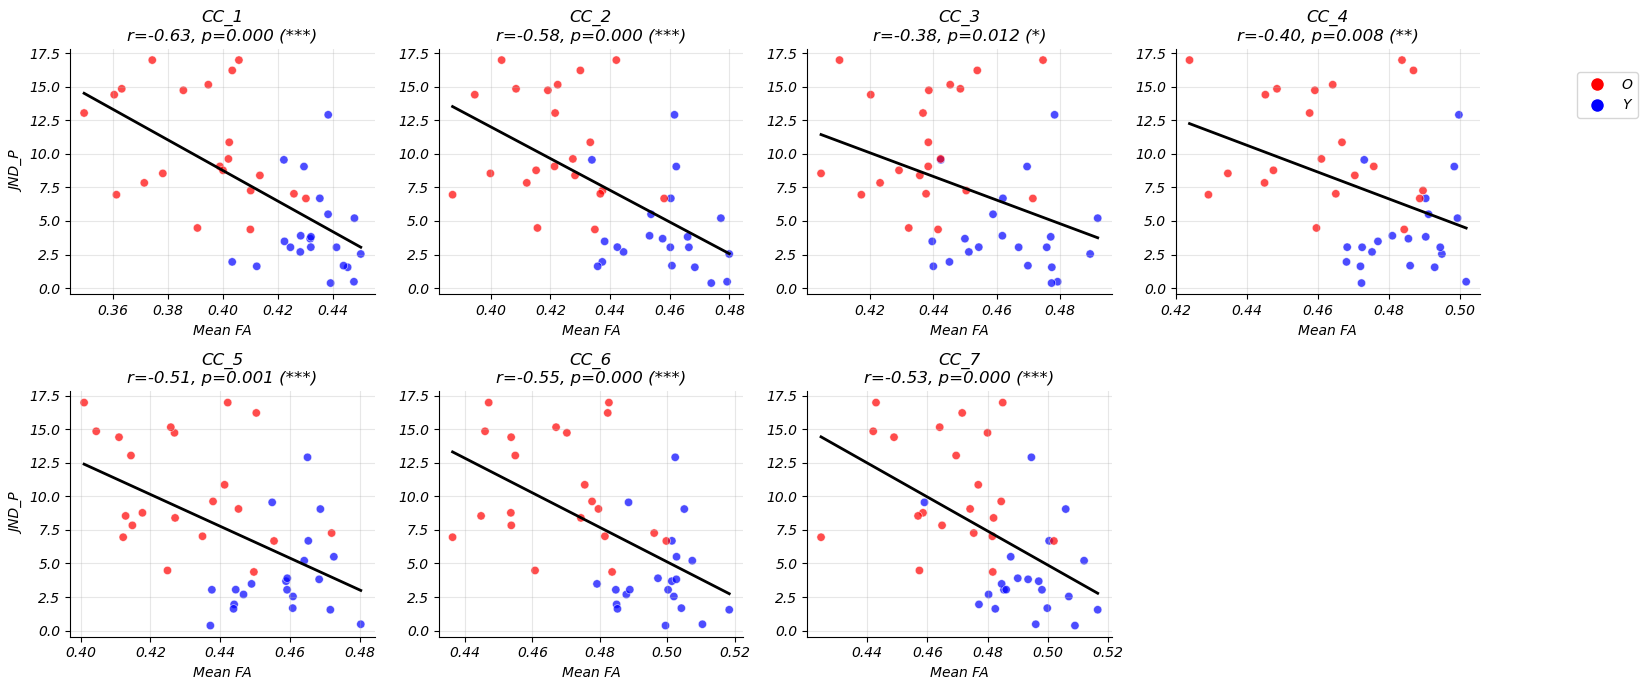

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create ONE figure
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

# Define colors for groups
group_colors = {'O': 'red', 'Y': 'blue'}

for i, CCx in enumerate(CCx_list):
    x = df_mean_FA[CCx]
    y = df_mean_FA['JND_P']
    group = df_mean_FA['group']

    # Compute regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    line = slope * x + intercept

    ax = axs[i]

    # Scatter plot with group colors
    sns.scatterplot(x=x, y=y, hue=group, palette=group_colors, alpha=0.7, ax=ax, legend=False)

    # Regression line (sorted for clean line)
    x_sorted = np.sort(x)
    line_sorted = slope * x_sorted + intercept
    ax.plot(x_sorted, line_sorted, color='black', linewidth=2)

    # Significance label
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."

    # Title with stats
    ax.set_title(f"{CCx}\nr={r_value:.2f}, p={p_value:.3f} ({sig})")

    # Labels
    ax.set_xlabel("Mean FA")
    if i % 4 == 0:
        ax.set_ylabel("JND_P")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.3)

# Remove empty subplot (8th)
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

# Add a legend for the groups
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=group)
           for group, color in group_colors.items()]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.1, 0.9))

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Regression intra-group Young vs Old
for CCx in CCx_list:    
    for group in df_mean_FA['group'].unique():
        mask = df_mean_FA['group'] == group
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_mean_FA[mask][CCx], df_mean_FA[mask]['JND_P'])
        print(f"{CCx} - {group}: slope={slope:.4f}, intercept={intercept:.4f}, r={r_value:.4f}, p={p_value:.4f}, std_err={std_err:.4f}")


CC_1 - Y: slope=-10.4226, intercept=8.6000, r=-0.0392, p=0.8659, std_err=60.8948
CC_1 - O: slope=-64.4416, intercept=35.8479, r=-0.3472, p=0.1230, std_err=39.9306
CC_2 - Y: slope=-30.2995, intercept=17.9565, r=-0.1385, p=0.5493, std_err=49.6950
CC_2 - O: slope=-36.0387, intercept=25.7785, r=-0.1477, p=0.5229, std_err=55.3699
CC_3 - Y: slope=-1.6728, intercept=4.8637, r=-0.0084, p=0.9710, std_err=45.4751
CC_3 - O: slope=33.1717, intercept=-3.9249, r=0.1395, p=0.5464, std_err=54.0075
CC_4 - Y: slope=86.3954, intercept=-37.8176, r=0.3118, p=0.1688, std_err=60.3943
CC_4 - O: slope=-28.6970, intercept=23.8283, r=-0.1358, p=0.5574, std_err=48.0448
CC_5 - Y: slope=72.8830, intercept=-29.2741, r=0.2779, p=0.2226, std_err=57.7952
CC_5 - O: slope=-64.8430, intercept=38.4489, r=-0.2920, p=0.1990, std_err=48.7250
CC_6 - Y: slope=13.9846, intercept=-2.8758, r=0.0441, p=0.8494, std_err=72.6424
CC_6 - O: slope=-42.2224, intercept=30.3372, r=-0.1810, p=0.4323, std_err=52.6285
CC_7 - Y: slope=-42.5393,

4. Linear Mixed Models

FA ~ JND + Age + (1|Subject)

In [ ]:
# Get the mean FA values only the segments 50 -5 et +5 

df_meanCC_FA = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    
    # select the values from segment seg_45 to seg_55
    #mean_values = mean_values.iloc[:, 43:54]
    mean_values = mean_values.iloc[:, 38:59] # from 50-5 to 50+5
    df_meanCC_FA[CCx] = mean_values.mean(axis=1)

# dataframe 
df_meanCC_FA['JND_P'] = sub_ID['JND_P']
df_meanCC_FA['group'] = sub_ID['group']
df_meanCC_FA

,CC_1,CC_2,CC_3,CC_4,CC_5,CC_6,CC_7,JND_P,group
0,0.510688,0.607035,0.628389,0.665628,0.510137,0.598790,0.664461,9.56,Y
1,0.541017,0.642248,0.667978,0.689853,0.530488,0.615821,0.697978,6.69,Y
2,0.519407,0.642363,0.679334,0.709053,0.555151,0.624651,0.717970,12.92,Y
3,0.488166,0.617327,0.638445,0.660893,0.508443,0.599758,0.702452,1.95,Y
4,0.529652,0.652346,0.676468,0.708776,0.561749,0.643317,0.748782,2.54,Y
5,0.487306,0.586592,0.599067,0.672706,0.514357,0.588662,0.681178,4.48,O
6,0.509435,0.606424,0.638076,0.628825,0.494410,0.594814,0.711989,9.63,O
7,0.497540,0.597112,0.625294,0.697490,0.568419,0.613552,0.686662,7.27,O
8,0.505502,0.612602,0.634607,0.681769,0.526689,0.599388,0.710907,1.62,Y
9,0.533015,0.638763,0.652136,0.695861,0.539282,0.620209,0.744046,3.68,Y


In [ ]:
# linear regression for predincting JND, covariate with group, for each CC (column) in the dataframe df_meanCC_FA

import statsmodels.formula.api as smf

for CCx in CCx_list:
    model = smf.ols(formula=f'JND_P ~ {CCx} : group', data=df_meanCC_FA).fit()
    print(f"Regression results for {CCx} (covariate: group):")
    print(model.summary())
    print("\n\n")

Regression results for CC_1 (covariate: group):
                             OLS Regression Results                            
Dep. Variable:                   JND_P   R-squared:                       0.407
Model:                             OLS   Adj. R-squared:                  0.371
Method:                  Least Squares   F-statistic:                     11.31
Date:              mer., 22 avril 2026   Prob (F-statistic):           0.000182
Time:                         15:38:06   Log-Likelihood:                -96.706
No. Observations:                   36   AIC:                             199.4
Df Residuals:                       33   BIC:                             204.2
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

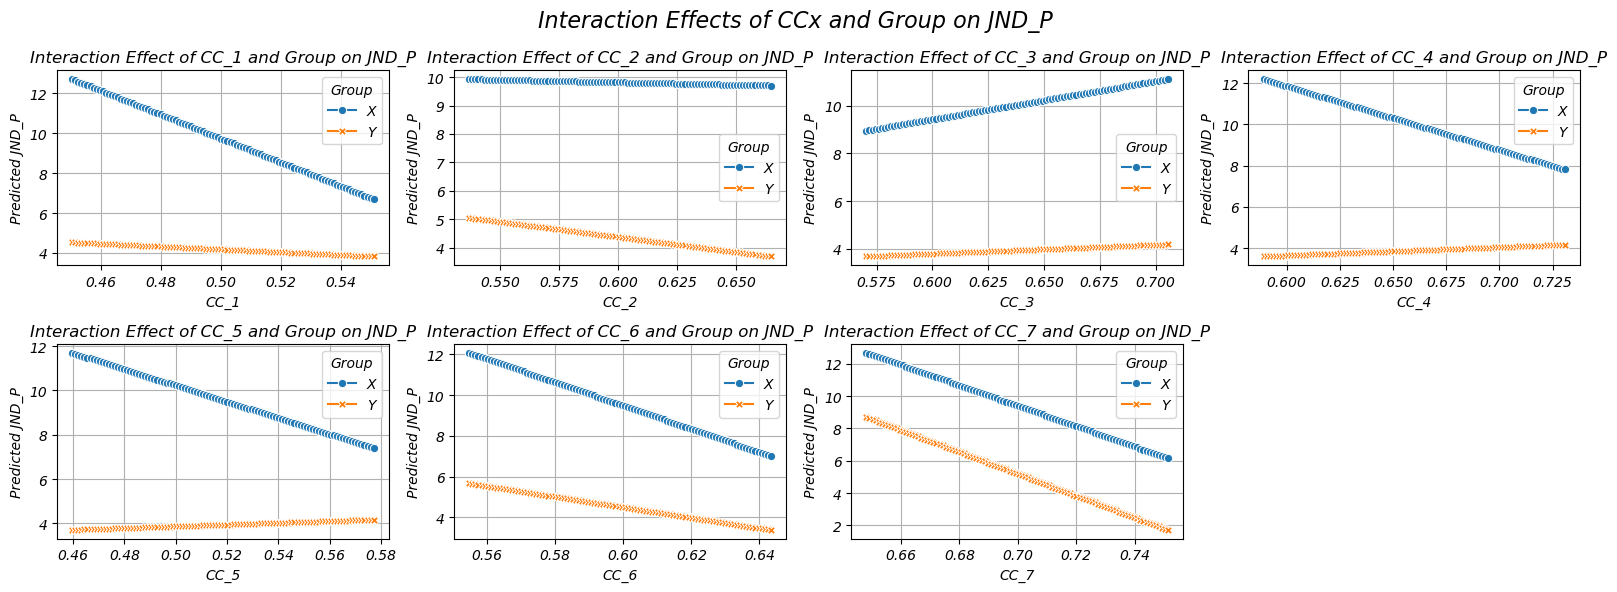

In [ ]:

# Assuming df_meanCC_FA is your DataFrame and CCx_list is your list of predictors
n_plots = len(CCx_list)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
fig.suptitle('Interaction Effects of CCx and Group on JND_P', fontsize=16)
axes = axes.flatten()  # Flatten the array for easy iteration

for i, CCx in enumerate(CCx_list):
    # Fit the model
    model = smf.ols(formula=f'JND_P ~ {CCx} * group', data=df_meanCC_FA).fit()

    # Extract coefficients
    intercept = model.params['Intercept']
    group_Y_coef = model.params.get(f'group[T.Y]', 0)
    CCx_coef = model.params[CCx]
    interaction_coef = model.params.get(f'{CCx}:group[T.Y]', 0)

    # Generate predicted values for plotting
    CCx_range = np.linspace(df_meanCC_FA[CCx].min(), df_meanCC_FA[CCx].max(), 100)

    # Predicted JND_P for Group X (reference)
    jnd_p_group_x = intercept + CCx_coef * CCx_range

    # Predicted JND_P for Group Y
    jnd_p_group_y = (intercept + group_Y_coef) + (CCx_coef + interaction_coef) * CCx_range

    # Create a DataFrame for plotting
    df_plot = pd.DataFrame({
        CCx: np.tile(CCx_range, 2),
        'JND_P': np.concatenate([jnd_p_group_x, jnd_p_group_y]),
        'Group': ['X'] * len(CCx_range) + ['Y'] * len(CCx_range)
    })

    # Plot on the i-th subplot
    sns.lineplot(data=df_plot, x=CCx, y='JND_P', hue='Group', style='Group', markers=True, dashes=False, ax=axes[i])
    axes[i].set_title(f'Interaction Effect of {CCx} and Group on JND_P')
    axes[i].set_xlabel(CCx)
    axes[i].set_ylabel('Predicted JND_P')
    axes[i].grid(True)
    axes[i].legend(title='Group')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Mediation model for this measure

In [ ]:
# standar scaler pour df_meanCC_FA
from sklearn.preprocessing import RobustScaler, StandardScaler
scaler = RobustScaler()
scaled_features = scaler.fit_transform(df_meanCC_FA.drop(['JND_P', 'group'], axis=1))
df_meanCC_FA_scaled = pd.DataFrame(scaled_features, columns=df_meanCC_FA.drop(['JND_P', 'group'], axis=1).columns)
df_meanCC_FA_scaled['JND_P'] = df_meanCC_FA['JND_P']
df_meanCC_FA_scaled['group'] = df_meanCC_FA['group']
df_meanCC_FA_scaled 

,CC_1,CC_2,CC_3,CC_4,CC_5,CC_6,CC_7,JND_P,group
0,-0.141807,-0.344439,-0.368641,-0.647806,-0.587836,-0.549340,-1.479143,9.56,Y
1,1.059050,0.712661,0.748804,0.161635,0.023451,0.114678,-0.424041,6.69,Y
2,0.203385,0.716132,1.069335,0.803201,0.764282,0.458910,0.205315,12.92,Y
3,-1.033593,-0.035471,-0.084795,-0.806016,-0.638711,-0.511585,-0.283194,1.95,Y
4,0.609031,1.015807,0.988444,0.793953,0.962477,1.186679,1.175280,2.54,Y
5,-1.067644,-0.958137,-1.196290,-0.411309,-0.461072,-0.944199,-0.952902,4.48,O
6,-0.191427,-0.362782,-0.095229,-1.877545,-1.060233,-0.704355,0.017037,9.63,O
7,-0.662434,-0.642329,-0.456001,0.416834,1.162807,0.026191,-0.780260,7.27,O
8,-0.347181,-0.177302,-0.193144,-0.108481,-0.090644,-0.526027,-0.017037,1.62,Y
9,0.742190,0.608056,0.301638,0.362405,0.287605,0.285724,1.026182,3.68,Y


In [ ]:
merged_df = pd.merge(df_meanCC_FA_scaled, sub_id)
merged_df

,CC_1,CC_2,CC_3,CC_4,CC_5,CC_6,CC_7,JND_P,group,sub,sex,age,IHD
0,-0.141807,-0.344439,-0.368641,-0.647806,-0.587836,-0.549340,-1.479143,9.56,Y,sub-01,F,25,0.534027
1,1.059050,0.712661,0.748804,0.161635,0.023451,0.114678,-0.424041,6.69,Y,sub-02,M,27,0.570600
2,0.203385,0.716132,1.069335,0.803201,0.764282,0.458910,0.205315,12.92,Y,sub-03,F,28,-0.140120
3,-1.033593,-0.035471,-0.084795,-0.806016,-0.638711,-0.511585,-0.283194,1.95,Y,sub-05,F,21,0.488581
4,0.609031,1.015807,0.988444,0.793953,0.962477,1.186679,1.175280,2.54,Y,sub-06,F,25,0.578001
5,-1.067644,-0.958137,-1.196290,-0.411309,-0.461072,-0.944199,-0.952902,4.48,O,sub-08,F,67,0.419239
6,-0.191427,-0.362782,-0.095229,-1.877545,-1.060233,-0.704355,0.017037,9.63,O,sub-09,M,73,0.246470
7,-0.662434,-0.642329,-0.456001,0.416834,1.162807,0.026191,-0.780260,7.27,O,sub-10,F,64,0.253942
8,-0.347181,-0.177302,-0.193144,-0.108481,-0.090644,-0.526027,-0.017037,1.62,Y,sub-11,F,21,0.268078
9,0.742190,0.608056,0.301638,0.362405,0.287605,0.285724,1.026182,3.68,Y,sub-12,M,21,0.115833


In [ ]:
import statsmodels.api as sm
from pingouin import mediation_analysis
# here I use the FA mean of the whole CC tracts to perform the mediation analysis between age and JND_P, with mean FA as mediator
df_CCs = merged_df.copy()

for i in range(1, 8): 
    cc_ROIs = f"CC_{i}"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'JND': df_CCs["JND_P"],
        'IHD': df_CCs["IHD"],
        'meanFA_center': df_CCs[cc_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='meanFA_center', y='JND', m='age', seed=42)
    print(f"Results for {cc_ROIs}:")
    print(mediation_results)
    print("\n")



Results for CC_1:
       path       coef        se      pval      CI2.5    CI97.5  sig
0   age ~ X -14.794179  3.360246  0.000084 -21.596642 -7.991716  Yes
1   Y ~ age   0.150719  0.026175  0.000001   0.097732  0.203707  Yes
2     Total  -3.086156  0.761971  0.000243  -4.628685 -1.543627  Yes
3    Direct  -1.293228  0.802034  0.115365  -2.918303  0.331846   No
4  Indirect  -1.792927  0.531108  0.000000  -3.114596 -0.820574  Yes


Results for CC_2:
       path       coef        se      pval      CI2.5     CI97.5  sig
0   age ~ X -17.563924  3.496041  0.000012 -24.641288 -10.486560  Yes
1   Y ~ age   0.150719  0.026175  0.000001   0.097732   0.203707  Yes
2     Total  -2.720635  0.892649  0.004180  -4.527708  -0.913561  Yes
3    Direct  -0.122170  0.951153  0.898493  -2.049389   1.805049   No
4  Indirect  -2.598465  0.762391  0.000000  -4.168092  -1.131118  Yes


Results for CC_3:
       path       coef        se      pval      CI2.5    CI97.5  sig
0   age ~ X -13.559481  3.565252  0.000

# Running Window analysis 


In [58]:
df_window_meanCC_FA = pd.DataFrame()
CClist= ['CC_4','CC_5']
#CClist= ['CC_1']

for CCx in CClist:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)

    scaler = RobustScaler()
    scaled_features = scaler.fit_transform(mean_values)
    mean_values = pd.DataFrame(scaled_features, columns=mean_values.columns)

    # select the values from segment in windows of 10: from 0 to 5, then from 3 to 8, etc.
    # so it is a running window of 6 segments, with a step of 3 segments
    # then each window will be meaned and saved in a new dataframe df_window_meanCC_FA, for a mediation analysis with age and JND_P
    for start in range(0, mean_values.shape[1] - 9, 4):
        window_mean = mean_values.iloc[:, start:start+9].mean(axis=1)
        df_window_meanCC_FA[f'{CCx}_window_{start}'] = window_mean

        # Mediation analysis for each window
        data = pd.DataFrame({
            'age': sub_id['age'],
            'JND': sub_id['JND_P'],
            'IHD' : sub_id['IHD'],
            'meanFA_window': window_mean
        })  
        mediation_results = mediation_analysis(data=data, x='age', y='IHD', m='meanFA_window', seed=42)
        print(f"Results for {CCx} window {start}-{start+9}:")
        print(mediation_results)
        print("\n")



Results for CC_4 window 0-9:
                path      coef        se      pval     CI2.5    CI97.5  sig
0  meanFA_window ~ X -0.016467  0.004094  0.000304 -0.024787 -0.008148  Yes
1  Y ~ meanFA_window  0.187937  0.094749  0.055431 -0.004616  0.380490   No
2              Total -0.011069  0.002195  0.000015 -0.015531 -0.006608  Yes
3             Direct -0.011770  0.002699  0.000119 -0.017260 -0.006279  Yes
4           Indirect  0.000700  0.001495  0.540000 -0.002402  0.003842   No


Results for CC_4 window 4-13:
                path      coef        se      pval     CI2.5    CI97.5  sig
0  meanFA_window ~ X -0.016884  0.005274  0.002964 -0.027602 -0.006165  Yes
1  Y ~ meanFA_window  0.140795  0.079122  0.084104 -0.020000  0.301591   No
2              Total -0.011069  0.002195  0.000015 -0.015531 -0.006608  Yes
3             Direct -0.011312  0.002541  0.000092 -0.016481 -0.006143  Yes
4           Indirect  0.000243  0.001038  0.700000 -0.002026  0.002340   No


Results for CC_4 window 8

# OTHER DTI MEASURES

In [24]:
import os
import pandas as pd
import numpy as np

# Define paths and lists
tracto_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/'
listsub = ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '19', '20', '21', '22', '23', '24', '25', '26',
           '27', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '41', '46', '47', '48', '49', '50', '51']

dti_metric_list = ['MD', 'AD', 'RD']
CCx_list = ['CC_4', 'CC_5']


for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(tracto_path, dti_metric, f'sub-{subj}_{dti_metric}_tractometry_MergedTOMs_last.csv')
            if os.path.exists(file_path):
                data_sub = pd.read_csv(file_path, sep=";")
                list_CCx_val.append(data_sub[CCx].values)
            else:
                print(f"File not found: {file_path}")

        # Convert list of arrays → DataFrame
        dfCCx = pd.DataFrame(list_CCx_val)

        # Rename columns seg_2, seg_3, ... up to length
        new_col_names = [f"seg_{i}" for i in range(2, 2 + dfCCx.shape[1])]
        dfCCx.columns = new_col_names

        # Save to CSV
        out_file = f"{CCx}_{dti_metric}.csv"
        #dfCCx.to_csv(out_file, index_label="Index")

        #print(f"Saved {out_file} with shape {dfCCx.shape}")

        print(f'Merging data for {CCx} and metric {dti_metric}')
        data_frames = pd.concat([sub_id, CCx_df], axis=1)
        #eliminnate repeated columns
        data_frames = data_frames.loc[:,~data_frames.columns.duplicated()]

        data_frames.to_csv(CCx +'_'+dti_metric+'.csv', index=False)

data_frames



Merging data for CC_4 and metric MD
Merging data for CC_5 and metric MD
Merging data for CC_4 and metric AD
Merging data for CC_5 and metric AD
Merging data for CC_4 and metric RD
Merging data for CC_5 and metric RD


,sub,sex,age,group,JND_P,IHD,Index,seg_2,seg_3,seg_4,...,seg_90,seg_91,seg_92,seg_93,seg_94,seg_95,seg_96,seg_97,seg_98,seg_99
0,sub-01,F,25,Y,9.5600,0.534027,0,0.418762,0.417729,0.407470,...,0.469598,0.481928,0.483172,0.488108,0.473649,0.466071,0.440999,0.427319,0.403513,0.393462
1,sub-02,M,27,Y,6.6900,0.570600,1,0.404477,0.413035,0.428793,...,0.444015,0.448520,0.448843,0.448736,0.448765,0.450751,0.450654,0.459984,0.468022,0.440925
2,sub-03,F,28,Y,12.9200,-0.140120,2,0.406107,0.418505,0.427785,...,0.405961,0.418104,0.417163,0.419064,0.421741,0.413694,0.419959,0.420513,0.417643,0.410188
3,sub-05,F,21,Y,1.9500,0.488581,3,0.410063,0.416538,0.422868,...,0.429454,0.431295,0.434488,0.437259,0.434522,0.435441,0.431261,0.437589,0.433865,0.427003
4,sub-06,F,25,Y,2.5400,0.578001,4,0.396116,0.397476,0.394420,...,0.416729,0.424758,0.428146,0.440622,0.440391,0.443677,0.456998,0.455532,0.438416,0.428815
5,sub-08,F,67,O,4.4800,0.419239,5,0.386719,0.388758,0.395112,...,0.365858,0.367887,0.370834,0.370909,0.379524,0.381565,0.381550,0.385264,0.392361,0.398818
6,sub-09,M,73,O,9.6300,0.246470,6,0.393598,0.403204,0.410278,...,0.418132,0.423144,0.422957,0.418825,0.422282,0.415637,0.417666,0.414637,0.409144,0.403871
7,sub-10,F,64,O,7.2700,0.253942,7,0.386592,0.393803,0.396475,...,0.428478,0.429575,0.430381,0.435593,0.429227,0.428271,0.421866,0.423889,0.410149,0.395229
8,sub-11,F,21,Y,1.6200,0.268078,8,0.389953,0.392493,0.382280,...,0.430783,0.422988,0.407577,0.401877,0.387241,0.377374,0.368563,0.361242,0.360466,0.370832
9,sub-12,M,21,Y,3.6800,0.115833,9,0.434319,0.440894,0.437677,...,0.433713,0.435300,0.442667,0.450949,0.448203,0.448729,0.451184,0.449638,0.447055,0.438828


In [37]:
# Get the mean FA values only the segments 50 -5 et +5 
out_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis/'
dti_metric = 'RD'

df_meanCC_DTI = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(out_path, f'{CCx}_{dti_metric}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    
    # select the values from segment seg_45 to seg_55
    #mean_values = mean_values.iloc[:, 43:54]
    mean_values = mean_values.iloc[:, 38:59] # from 50-5 to 50+5
    df_meanCC_DTI[CCx] = mean_values.mean(axis=1)
    df_meanCC_DTI = pd.concat([sub_id, df_meanCC_DTI], axis=1)
    df_meanCC_DTI = df_meanCC_DTI.loc[:,~df_meanCC_DTI.columns.duplicated()]

# dataframe 
df_meanCC_DTI

# Mediation analysis for each CCx with age as predictor, JND_P as outcome, and mean DTI value as mediator
from pingouin import mediation_analysis

for CCx in CCx_list:
    data = pd.DataFrame({
        'age': df_meanCC_DTI["age"],
        'JND': df_meanCC_DTI["JND_P"],
        'IHD': df_meanCC_DTI["IHD"],
        'meanDTI_center': df_meanCC_DTI[CCx],
    })
    # Mediation analysis
    mediation_results[CCx] = mediation_analysis(data=data, x='age', y='JND', m='meanDTI_center', seed=42)
    print(f"Results for {CCx}:")
    print(mediation_results[CCx])
    print("\n")

Results for CC_4:
                 path       coef         se      pval       CI2.5     CI97.5  \
0  meanDTI_center ~ X  -0.000643   0.000178  0.000996   -0.001005  -0.000280   
1  Y ~ meanDTI_center -67.783567  26.047110  0.013618 -120.717662 -14.849471   
2               Total   0.131859   0.026551  0.000019    0.077901   0.185818   
3              Direct   0.122000   0.031510  0.000483    0.057893   0.186107   
4            Indirect   0.009860   0.019376  0.624000   -0.022129   0.055936   

   sig  
0  Yes  
1  Yes  
2  Yes  
3  Yes  
4   No  


Results for CC_5:
                 path       coef         se      pval       CI2.5     CI97.5  \
0  meanDTI_center ~ X  -0.000643   0.000178  0.000996   -0.001005  -0.000280   
1  Y ~ meanDTI_center -67.783567  26.047110  0.013618 -120.717662 -14.849471   
2               Total   0.131859   0.026551  0.000019    0.077901   0.185818   
3              Direct   0.122000   0.031510  0.000483    0.057893   0.186107   
4            Indirect   0.0

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler
scaler = RobustScaler()

df_window_meanCC_DTI = pd.DataFrame()
CClist= ['CC_5']
dti_metric_list = ['MD', 'AD', 'RD']

for CCx in CClist:
    for dti_metric in dti_metric_list:
        file_path = os.path.join(CC_path, f'{CCx}_{dti_metric}.csv')
        dfCCx = pd.read_csv(file_path, sep=",")
        dfCCx = dfCCx.dropna()
        # drop the columns that are not numeric :
        mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
        scaler = RobustScaler()
        scaled_features = scaler.fit_transform(mean_values)
        mean_values = pd.DataFrame(scaled_features, columns=mean_values.columns)

        # select the values from segment in windows of 10: from 0 to 9, then from 3 to 12, etc.
        
        for start in range(0, mean_values.shape[1] - 9, 4):
            window_mean = mean_values.iloc[:, start:start+9].mean(axis=1)
            df_window_meanCC_DTI[f'{CCx}_{dti_metric}_window_{start}'] = window_mean

            # Mediation analysis for each window
            data = pd.DataFrame({
                'age': sub_id['age'],
                'JND': sub_id['JND_P'],
                'IHD' : sub_id['IHD'],
                'meanDTI_window': window_mean
            })  
            mediation_results = mediation_analysis(data=data, x='age', y='IHD', m='meanDTI_window', seed=42)
            print(f"DTI: {dti_metric} - Results for {CCx} window {start}-{start+9}:")
            print(mediation_results)
            print("\n")

# Results --> for predicting JND, none of the metrics (MD RD AD) in CC5 and CC4show a significant mediation effect. 
# However, for predicting IHD, there is a significant mediation effect of RD and MD in CC4 and in CC5 in segments : 84-93. And we find the same for FA

DTI: MD - Results for CC_5 window 0-9:
                 path      coef        se      pval     CI2.5    CI97.5  sig
0  meanDTI_window ~ X -0.016818  0.004473  0.000640 -0.025907 -0.007728  Yes
1  Y ~ meanDTI_window  0.173240  0.088679  0.059020 -0.006976  0.353457   No
2               Total -0.011069  0.002195  0.000015 -0.015531 -0.006608  Yes
3              Direct -0.011547  0.002647  0.000119 -0.016932 -0.006162  Yes
4            Indirect  0.000478  0.001199  0.648000 -0.001852  0.003013   No


DTI: MD - Results for CC_5 window 4-13:
                 path      coef        se      pval     CI2.5    CI97.5  sig
0  meanDTI_window ~ X -0.018301  0.004665  0.000404 -0.027782 -0.008821  Yes
1  Y ~ meanDTI_window  0.179685  0.082985  0.037475  0.011039  0.348331  Yes
2               Total -0.011069  0.002195  0.000015 -0.015531 -0.006608  Yes
3              Direct -0.011303  0.002685  0.000185 -0.016765 -0.005841  Yes
4            Indirect  0.000233  0.001145  0.768000 -0.002127  0.002269 